In [88]:
import pandas as pd
import numpy as np
import seaborn as sns
import torch
import torch.nn as nn
from sklearn.model_selection import train_test_split
from torch.utils.data import TensorDataset, DataLoader
from sklearn.preprocessing import StandardScaler

In [89]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device

device(type='cuda')

In [90]:
df = pd.read_csv("accident.csv") #Dataset URL -> https://www.kaggle.com/datasets/shubhambathwal/flight-price-prediction

In [91]:
df.shape

(307973, 21)

In [92]:
labels = df["Accident_Severity"]
df = df.drop(columns=["Accident Date","Accident_Index","Time","Accident_Severity","Number_of_Casualties"],axis=1)


In [93]:
df = df.drop("Carriageway_Hazards", axis = 1)
df.head()

,Day_of_Week,Junction_Control,Junction_Detail,Latitude,Light_Conditions,Local_Authority_(District),Longitude,Number_of_Vehicles,Police_Force,Road_Surface_Conditions,Road_Type,Speed_limit,Urban_or_Rural_Area,Weather_Conditions,Vehicle_Type
0,Thursday,Give way or uncontrolled,T or staggered junction,51.512273,Daylight,Kensington and Chelsea,-0.201349,2,Metropolitan Police,Dry,One way street,30,Urban,Fine no high winds,Car
1,Monday,Give way or uncontrolled,Crossroads,51.514399,Daylight,Kensington and Chelsea,-0.199248,2,Metropolitan Police,Wet or damp,Single carriageway,30,Urban,Fine no high winds,Taxi/Private hire car
2,Sunday,Give way or uncontrolled,T or staggered junction,51.486668,Daylight,Kensington and Chelsea,-0.179599,2,Metropolitan Police,Dry,Single carriageway,30,Urban,Fine no high winds,Taxi/Private hire car
3,Monday,Auto traffic signal,T or staggered junction,51.507804,Daylight,Kensington and Chelsea,-0.203110,2,Metropolitan Police,Frost or ice,Single carriageway,30,Urban,Other,Motorcycle over 500cc
4,Tuesday,Auto traffic signal,Crossroads,51.482076,Darkness - lights lit,Kensington and Chelsea,-0.173445,2,Metropolitan Police,Dry,Single carriageway,30,Urban,Fine no high winds,Car


In [94]:
df["Urban_or_Rural_Area"].value_counts()

Urban_or_Rural_Area
Urban    198532
Rural    109441
Name: count, dtype: int64

In [95]:
df.head()

,Day_of_Week,Junction_Control,Junction_Detail,Latitude,Light_Conditions,Local_Authority_(District),Longitude,Number_of_Vehicles,Police_Force,Road_Surface_Conditions,Road_Type,Speed_limit,Urban_or_Rural_Area,Weather_Conditions,Vehicle_Type
0,Thursday,Give way or uncontrolled,T or staggered junction,51.512273,Daylight,Kensington and Chelsea,-0.201349,2,Metropolitan Police,Dry,One way street,30,Urban,Fine no high winds,Car
1,Monday,Give way or uncontrolled,Crossroads,51.514399,Daylight,Kensington and Chelsea,-0.199248,2,Metropolitan Police,Wet or damp,Single carriageway,30,Urban,Fine no high winds,Taxi/Private hire car
2,Sunday,Give way or uncontrolled,T or staggered junction,51.486668,Daylight,Kensington and Chelsea,-0.179599,2,Metropolitan Police,Dry,Single carriageway,30,Urban,Fine no high winds,Taxi/Private hire car
3,Monday,Auto traffic signal,T or staggered junction,51.507804,Daylight,Kensington and Chelsea,-0.203110,2,Metropolitan Police,Frost or ice,Single carriageway,30,Urban,Other,Motorcycle over 500cc
4,Tuesday,Auto traffic signal,Crossroads,51.482076,Darkness - lights lit,Kensington and Chelsea,-0.173445,2,Metropolitan Police,Dry,Single carriageway,30,Urban,Fine no high winds,Car


In [96]:
# data.head()

In [97]:
x = {"Urban":1, "Rural":0}
# df["Urban_or_Rural_Area"] = df["Urban_or_Rural_Area"].map(x)
data = pd.get_dummies(df, columns=["Day_of_Week","Junction_Control","Junction_Detail","Light_Conditions","Local_Authority_(District)", "Police_Force","Road_Surface_Conditions","Road_Type","Weather_Conditions",  "Vehicle_Type" ,"Urban_or_Rural_Area" ] ,drop_first=True, dtype=int)

In [98]:
scaler = StandardScaler()
scal_cols = ["Latitude","Longitude","Speed_limit"]
data[scal_cols] = scaler.fit_transform(data[scal_cols])

In [99]:
data = data.values

In [100]:
for i in range(len(labels)):
    if labels[i] == "Fetal"  :
        labels[i] = "Fatal"
    

In [101]:
labels.value_counts()

Accident_Severity
Slight     263280
Serious     40740
Fatal        3953
Name: count, dtype: int64

In [102]:
labels = labels.map({"Slight":0, "Serious":1, "Fatal":2})

In [103]:
labels.value_counts()

Accident_Severity
0    263280
1     40740
2      3953
Name: count, dtype: int64

In [104]:
X_train, X_test, Y_train, Y_test = train_test_split(data, labels ,test_size=0.2, random_state=42)
Y_train.dtype

dtype('int64')

In [105]:
Y_train.shape, Y_test.shape

((246378,), (61595,))

In [106]:
X_train= torch.tensor(X_train, dtype=torch.float).to(device)
X_test= torch.tensor(X_test, dtype=torch.float).to(device)
Y_train = torch.tensor(Y_train.to_numpy(), dtype=torch.long).to(device)
Y_test = torch.tensor(Y_test.to_numpy(), dtype=torch.long).to(device)


In [157]:
class AccidentModel(nn.Module):
    def __init__(self, input_size):
        super().__init__()
        self.input_size = input_size
        self.layers = nn.Sequential(
            nn.Linear(input_size, 50),
            nn.ReLU(),
            nn.Linear(50,50),
            # nn.Dropout(0.05),
            nn.ReLU(),
            nn.Linear(50,3),
        )

    def forward(self, x):
        return self.layers(x)

In [158]:
torch.manual_seed(42)
input_size = len(labels)
model = AccidentModel(input_size=529).to(device)
loss_func = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(params=model.parameters(), lr = 0.01)

In [159]:
train_dataset = TensorDataset(X_train, Y_train)
test_dataset = TensorDataset(X_test, Y_test)

train_loader =  DataLoader(train_dataset,batch_size=256,  shuffle=True)
test_loader = DataLoader(test_dataset,batch_size=256,  shuffle=False)

In [169]:
%%time
epochs = 200
training_loss = []
testing_loss = []
epoch_c = []
model.load_state_dict(torch.load("accident.pth"))
for epoch in range(epochs):
    model.train()
    for X_batch, Y_batch in train_loader:
        X_batch, Y_batch = X_batch.to(device), Y_batch.to(device)
        Y_logits = model(X_batch)
        # print(Y_logits.shape)
        loss = loss_func(Y_logits, Y_batch)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        # torch.save(model.state_dict(), "accident.pth")
        
    model.eval()
    with torch.inference_mode():
        for X_batch, Y_batch in test_loader:
            X_batch, Y_batch = X_batch.to(device), Y_batch.to(device)
            Y_test_logits = model(X_batch)
            test_loss = loss_func(Y_test_logits, Y_batch)
    training_loss.append(loss.item())
    testing_loss.append(test_loss.item())
    epoch_c.append(epoch)
        
    # if epoch%10 == 0:
    print(f"Epoch {epoch} | Train Loss : {loss} | Test Loss : {test_loss}") 
    torch.save(model.state_dict(), "accident.pth")

Epoch 0 | Train Loss : 0.4680699110031128 | Test Loss : 0.41941410303115845
Epoch 1 | Train Loss : 0.47563377022743225 | Test Loss : 0.4217175841331482
Epoch 2 | Train Loss : 0.409779816865921 | Test Loss : 0.4214017391204834
Epoch 3 | Train Loss : 0.49583205580711365 | Test Loss : 0.4160234034061432
Epoch 4 | Train Loss : 0.47545766830444336 | Test Loss : 0.4183761179447174
Epoch 5 | Train Loss : 0.35672932863235474 | Test Loss : 0.4172850549221039
Epoch 6 | Train Loss : 0.36199483275413513 | Test Loss : 0.4165881872177124
Epoch 7 | Train Loss : 0.445134699344635 | Test Loss : 0.4221721589565277
Epoch 8 | Train Loss : 0.3620259761810303 | Test Loss : 0.41808396577835083
Epoch 9 | Train Loss : 0.3478476107120514 | Test Loss : 0.41749534010887146
Epoch 10 | Train Loss : 0.4346363842487335 | Test Loss : 0.41782742738723755
Epoch 11 | Train Loss : 0.414731502532959 | Test Loss : 0.417686402797699
Epoch 12 | Train Loss : 0.4509265720844269 | Test Loss : 0.4207005798816681
Epoch 13 | Train 

[]

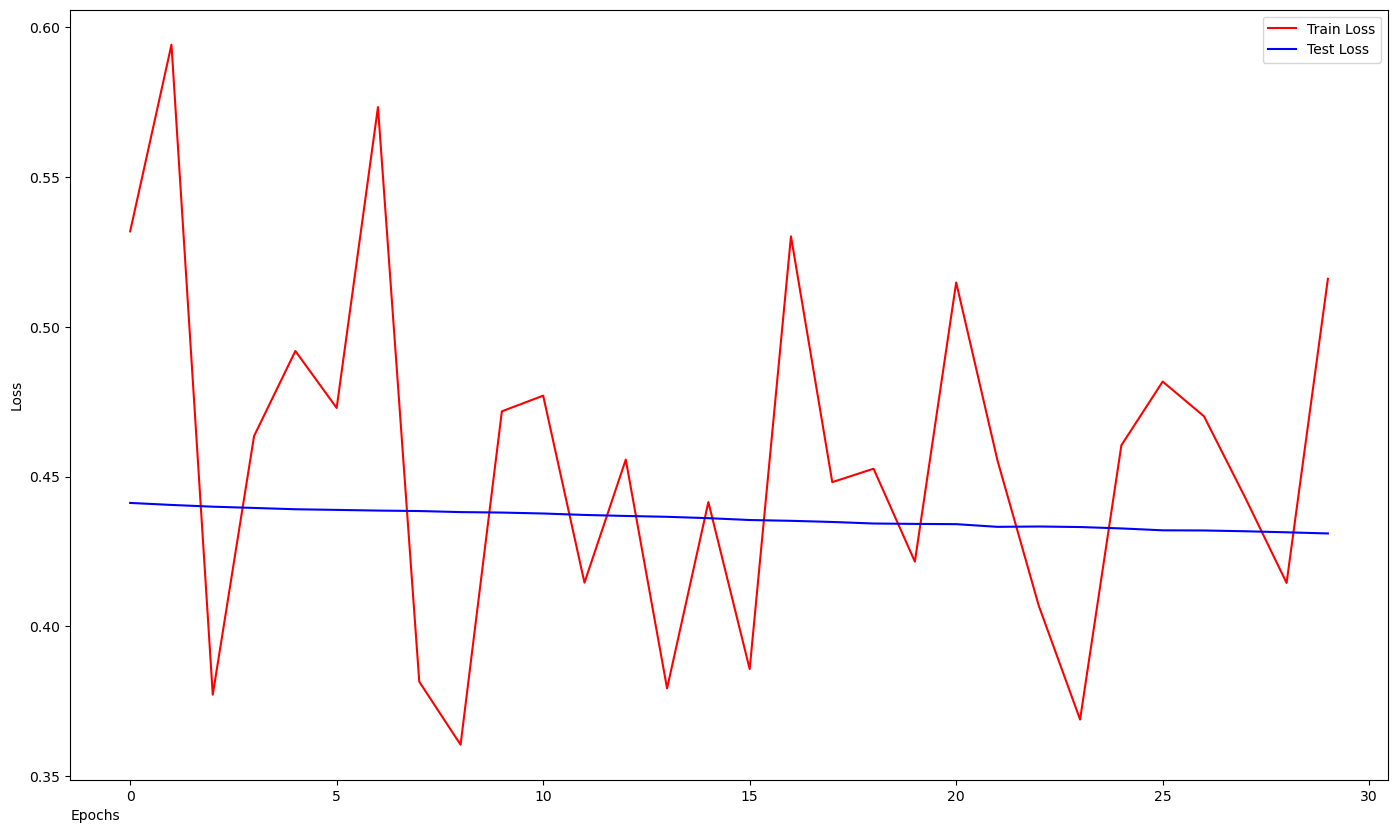

In [149]:

import matplotlib.pyplot as plt
plt.figure(figsize=(17.0,10.0))
plt.xlabel("Epochs",loc='left')
plt.ylabel("Loss")
plt.plot(epoch_c, training_loss, c="red",label="Train Loss")
plt.plot(epoch_c, testing_loss, c="blue",label = "Test Loss")
plt.legend()
plt.plot()

[]

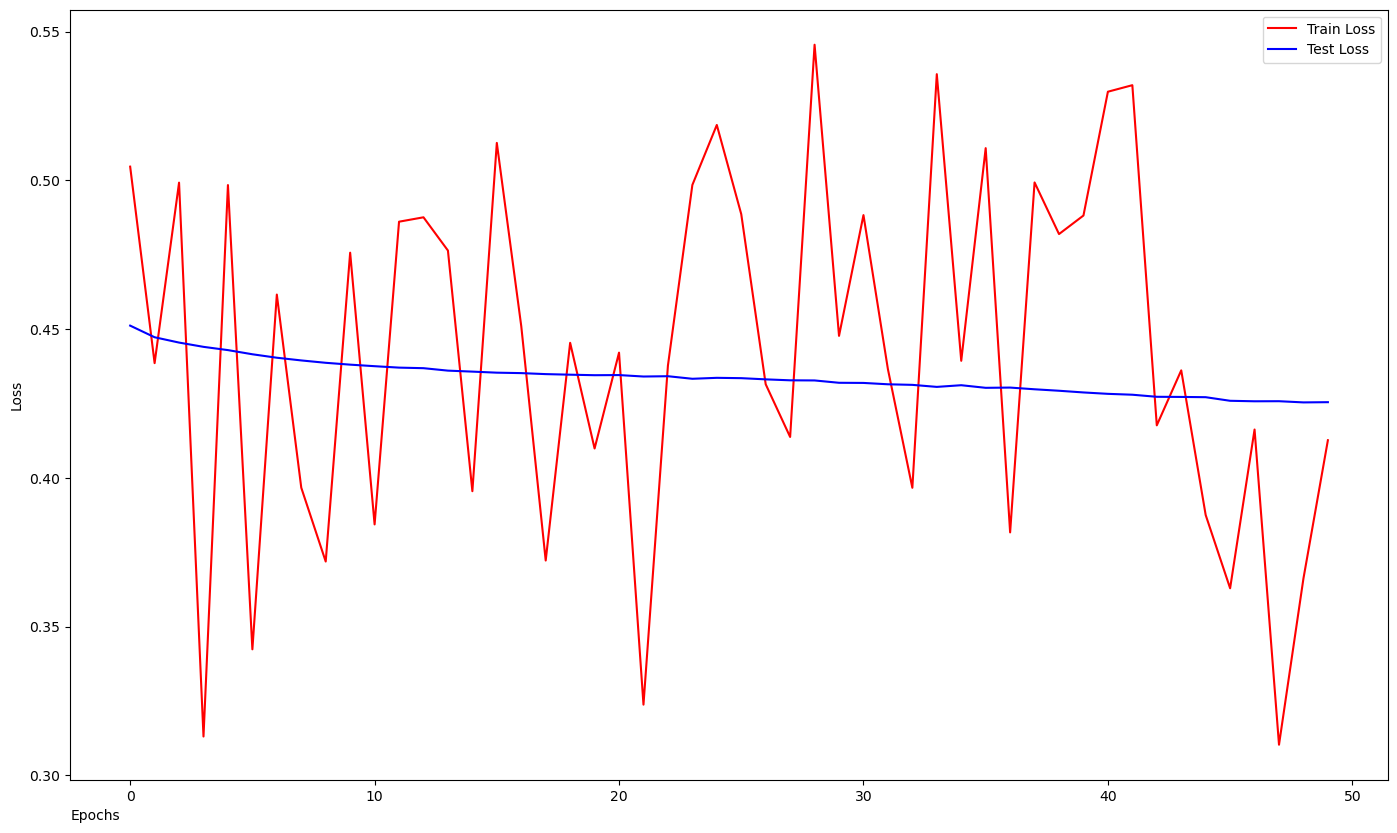

In [154]:
plt.figure(figsize=(17.0,10.0))
plt.xlabel("Epochs",loc='left')
plt.ylabel("Loss")
plt.plot(epoch_c, training_loss, c="red",label="Train Loss")
plt.plot(epoch_c, testing_loss, c="blue",label = "Test Loss")
plt.legend()
plt.plot()

[]

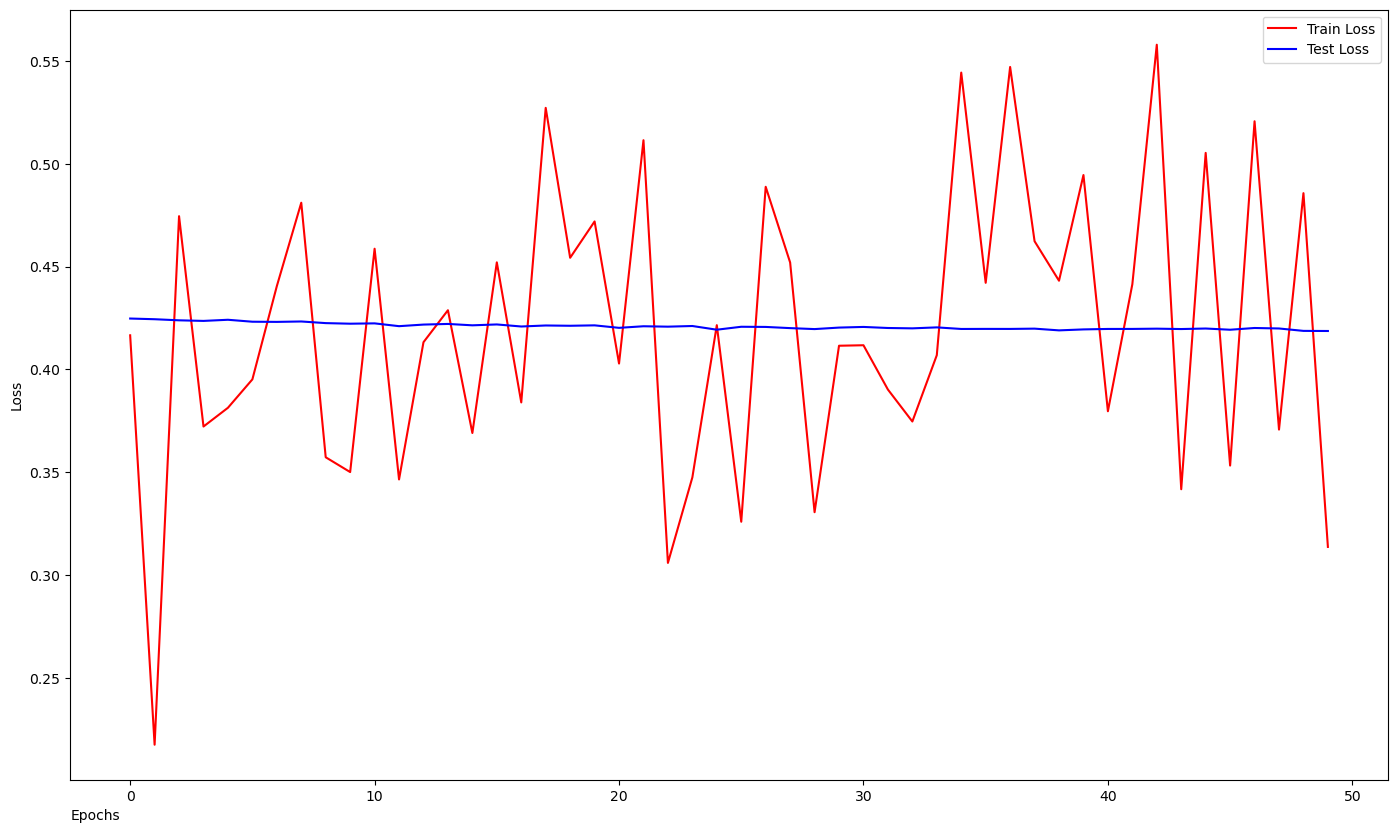

In [156]:
plt.figure(figsize=(17.0,10.0))
plt.xlabel("Epochs",loc='left')
plt.ylabel("Loss")
plt.plot(epoch_c, training_loss, c="red",label="Train Loss")
plt.plot(epoch_c, testing_loss, c="blue",label = "Test Loss")
plt.legend()
plt.plot()

[]

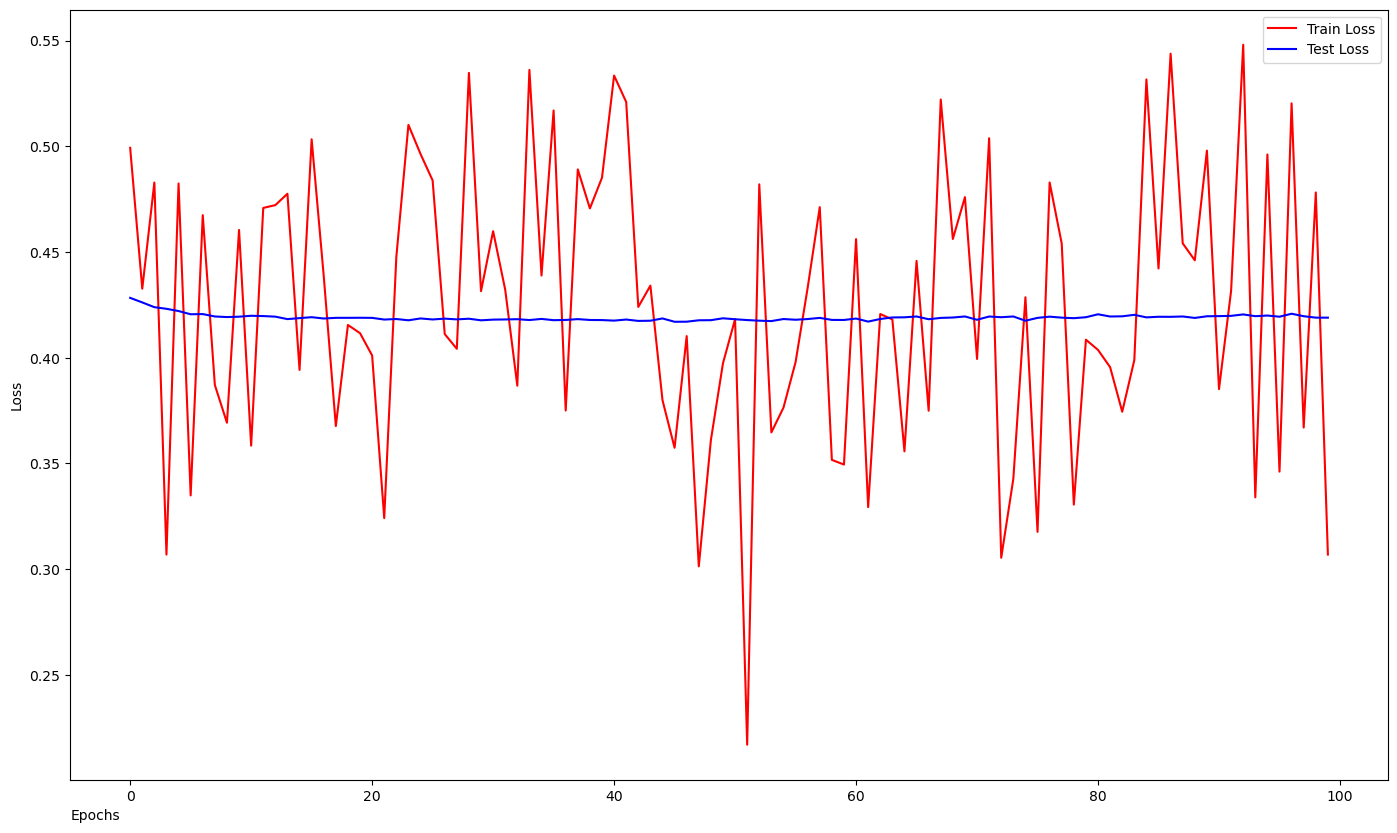

In [162]:
plt.figure(figsize=(17.0,10.0))
plt.xlabel("Epochs",loc='left')
plt.ylabel("Loss")
plt.plot(epoch_c, training_loss, c="red",label="Train Loss")
plt.plot(epoch_c, testing_loss, c="blue",label = "Test Loss")
plt.legend()
plt.plot()

[]

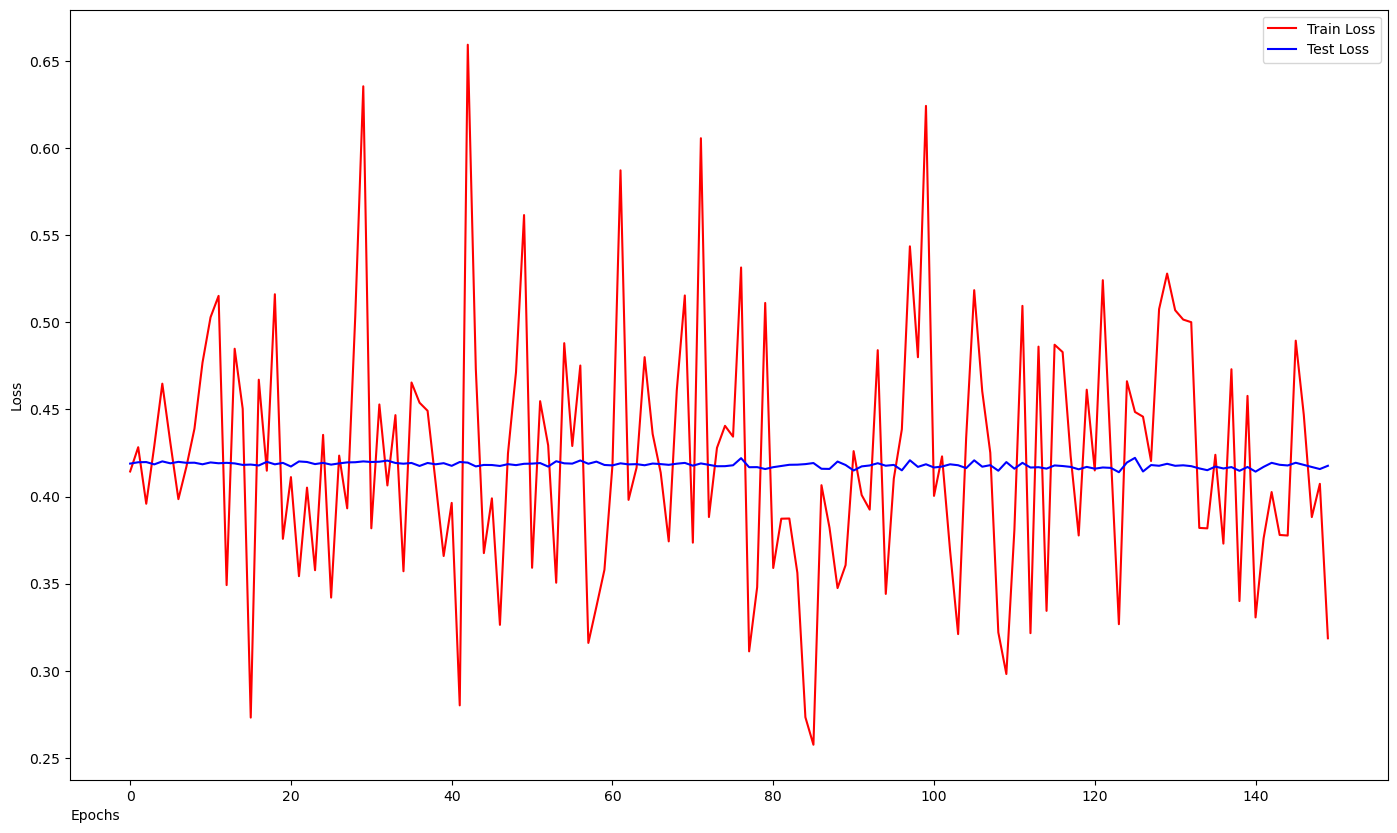

In [166]:
plt.figure(figsize=(17.0,10.0))
plt.xlabel("Epochs",loc='left')
plt.ylabel("Loss")
plt.plot(epoch_c, training_loss, c="red",label="Train Loss")
plt.plot(epoch_c, testing_loss, c="blue",label = "Test Loss")
plt.legend()
plt.plot()

[]

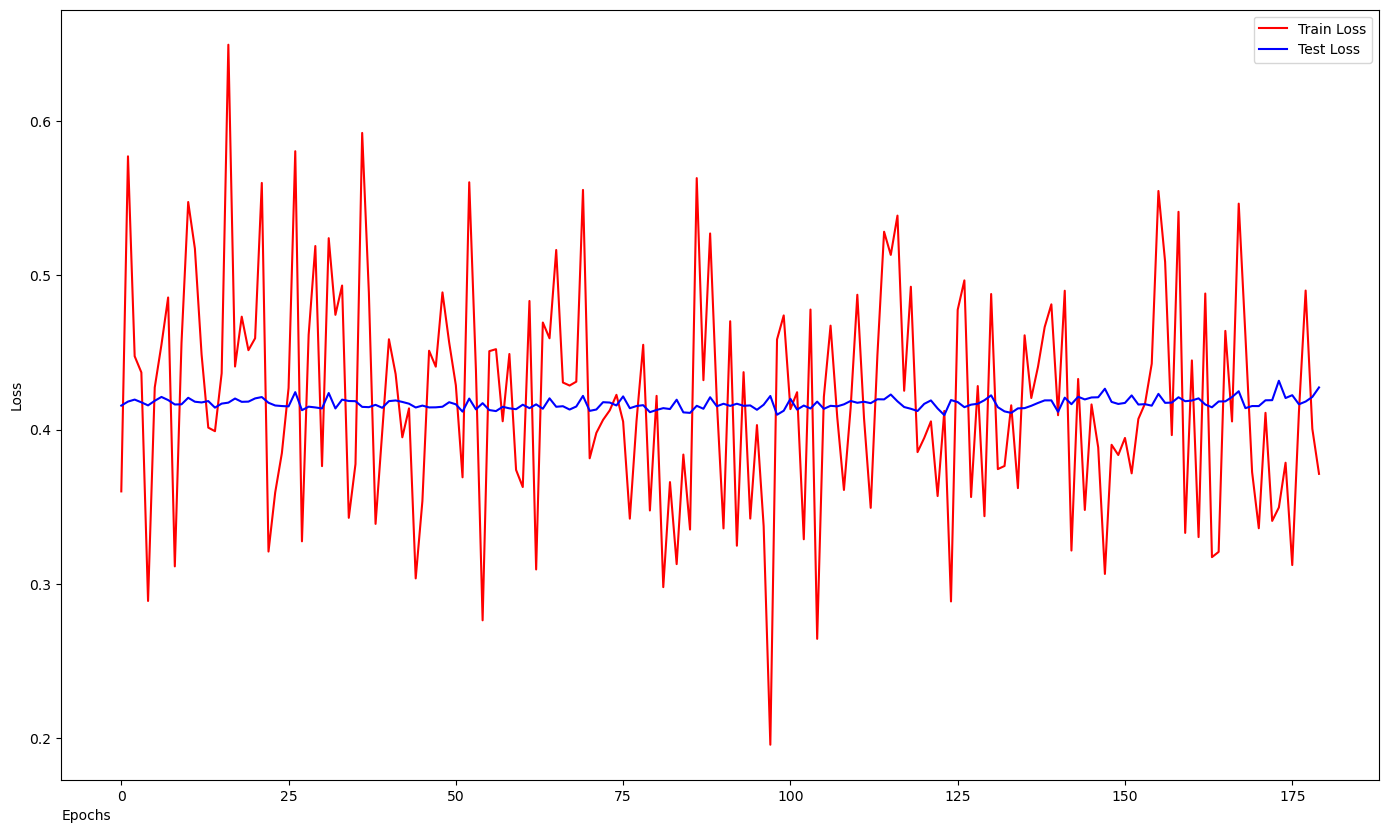

In [168]:
plt.figure(figsize=(17.0,10.0))
plt.xlabel("Epochs",loc='left')
plt.ylabel("Loss")
plt.plot(epoch_c, training_loss, c="red",label="Train Loss")
plt.plot(epoch_c, testing_loss, c="blue",label = "Test Loss")
plt.legend()
plt.plot()

[]

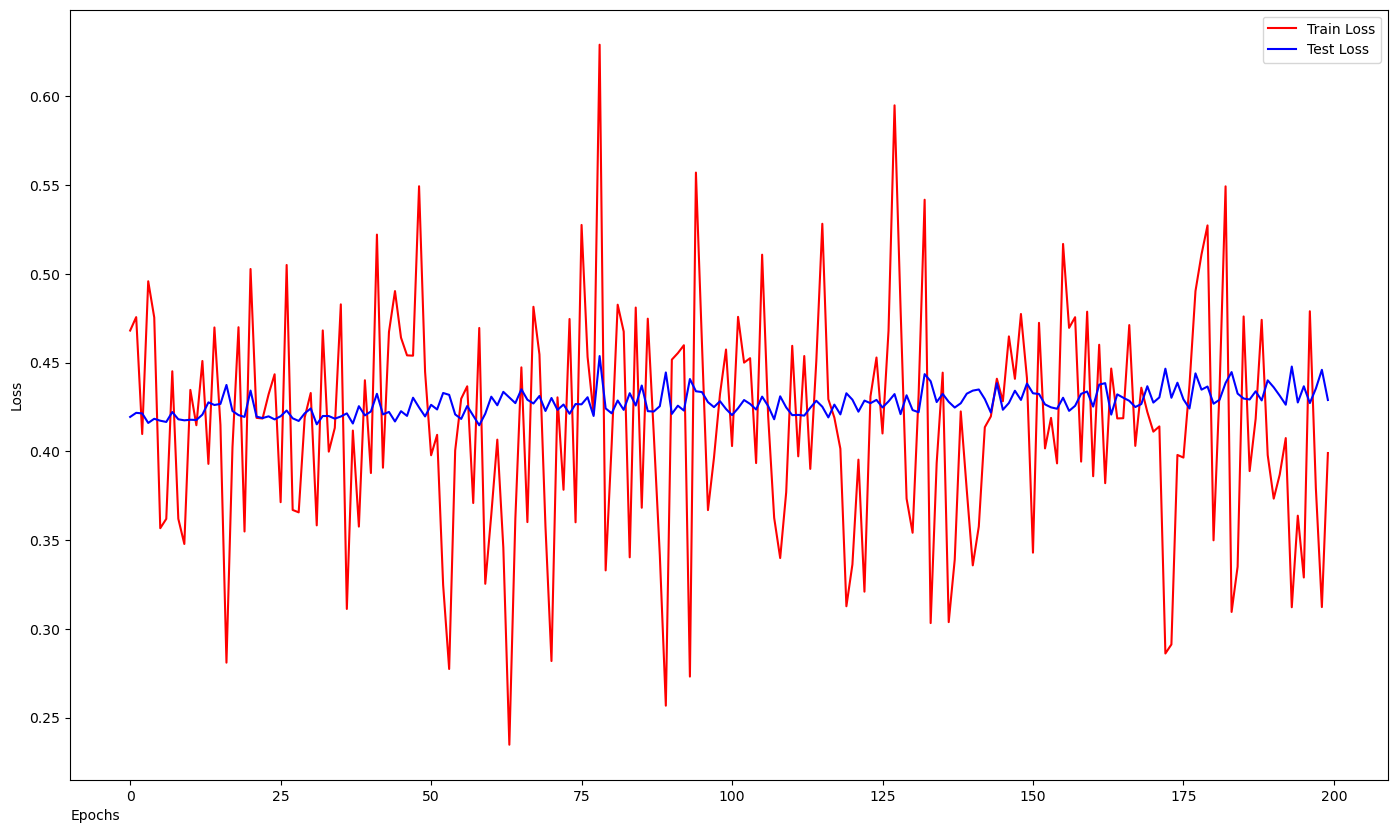

In [170]:
plt.figure(figsize=(17.0,10.0))
plt.xlabel("Epochs",loc='left')
plt.ylabel("Loss")
plt.plot(epoch_c, training_loss, c="red",label="Train Loss")
plt.plot(epoch_c, testing_loss, c="blue",label = "Test Loss")
plt.legend()
plt.plot()